## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es un tipo de red neuronal que está pensada para trabajar con imágenes. En este caso la voy a utilizar porque BloodMNIST contiene imágenes de células sanguíneas y necesito que el modelo pueda encontrar características visuales.

Por ejemplo, la red puede aprender características como:

- La forma y el tamaño de las células.
- Los bordes.
- Las texturas.
- Las estructuras que aparecen dentro de las células.
- Las diferencias visuales entre las diferentes clases.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**  
La utilizo para que la red pueda extraer características de las imágenes mediante filtros.

**(b) BatchNorm**  
La agrego para ayudar a que el entrenamiento sea más estable y también como parte de la regularización.

**(c) ReLU**  
La utilizo para agregar no linealidad y permitir que la red aprenda relaciones más complejas.

**(d) MaxPooling**  
La utilizo para reducir el tamaño de las características y disminuir el costo computacional.

**(e) Dropout**  
Lo agrego para que la red no dependa demasiado de unas pocas neuronas y así reducir el riesgo de overfitting.

**(f) Capas fully-connected**  
Al final utilizan las características que aprendió la CNN para decidir a qué clase pertenece cada imagen.


## 2. Preparación del entorno

Para realizar el ejercicio voy a utilizar **PyTorch**, `torchvision`, `medmnist`, `numpy`, `matplotlib`, `scikit-learn` y `tqdm`.

Primero instalo las librerías necesarias para asegurarme de que el notebook tenga todo lo que necesito para cargar el dataset, entrenar los modelos y evaluar los resultados.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

## 3. Cargar el dataset médico (BloodMNIST)

En este ejercicio voy a cambiar el dataset del ejemplo original por **BloodMNIST**.

Para que el problema sea más sencillo y se pueda trabajar como una clasificación binaria, voy a utilizar solamente **dos clases de células sanguíneas**: **Basophil (clase 0)** y **Eosinophil (clase 1)**.

Así puedo mantener la estructura del ejemplo, pero adaptándola a un problema de dos clases. También voy a aplicar regularización, data augmentation y control del learning rate para tratar de mantener el overfitting lo más bajo posible.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "bloodmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

# Voy a trabajar solamente con estas dos clases
selected_classes = [0, 1]
selected_names = [
    info["label"]["0"],
    info["label"]["1"]
]

print("Dataset:", data_flag)
print("Clases utilizadas:", selected_names)
print("Número de clases utilizadas:", len(selected_classes))
print("Canales:", info["n_channels"])
print("Tarea original:", info["task"])


Dataset: bloodmnist
Clases utilizadas: ['basophil', 'eosinophil']
Número de clases utilizadas: 2
Canales: 3
Tarea original: multi-class


In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_full = DataClass(
    split="train",
    transform=transform_basic,
    download=True
)

val_full = DataClass(
    split="val",
    transform=transform_basic,
    download=True
)

test_full = DataClass(
    split="test",
    transform=transform_basic,
    download=True
)

def get_class_indices(dataset, classes):
    labels = np.array(dataset.labels).reshape(-1)
    return np.where(np.isin(labels, classes))[0].tolist()

train_indices = get_class_indices(train_full, selected_classes)
val_indices = get_class_indices(val_full, selected_classes)
test_indices = get_class_indices(test_full, selected_classes)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)
test_dataset = Subset(test_full, test_indices)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


100%|██████████| 35.5M/35.5M [00:07<00:00, 4.83MB/s]


Train: 3033
Validation: 434
Test: 868


### 3.1. Visualizar ejemplos

Antes de empezar a entrenar, quiero ver algunas imágenes del dataset.

Esto me sirve para comprobar que las imágenes se están cargando correctamente y también para tener una idea de cómo son visualmente las diferentes clases de BloodMNIST.


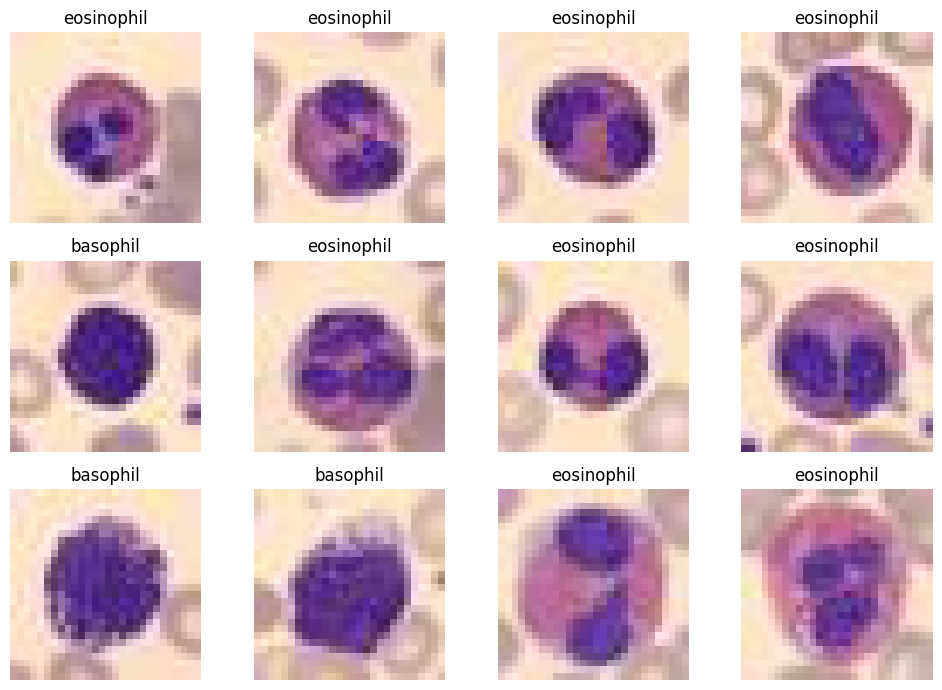

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 7))

    for i in range(min(n, len(dataset))):
        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)
        img = x.permute(1, 2, 0).numpy()
        plt.imshow(img)

        label = int(y.item())
        plt.title(selected_names[label])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Ahora voy a preparar los `DataLoader` para poder enviar las imágenes al modelo en grupos o **batches**.

También voy a comprobar si tengo disponible una GPU. Si existe, la utilizaré para acelerar el entrenamiento; de lo contrario, el código trabajará con CPU.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

x_batch, y_batch = next(iter(train_loader))

print("Forma de imágenes:", x_batch.shape)
print("Forma de etiquetas:", y_batch.shape)

Forma de imágenes: torch.Size([128, 3, 28, 28])
Forma de etiquetas: torch.Size([128, 1])


## 5. Modelo 1: CNN entrenada desde cero

Primero voy a crear una CNN desde cero, es decir, sin utilizar pesos que hayan sido aprendidos previamente.

No quiero hacer una red demasiado grande porque eso podría aumentar el riesgo de **overfitting**. Por eso voy a utilizar una arquitectura relativamente pequeña, pero agregando algunas técnicas de regularización:

- **BatchNorm2d** para estabilizar el entrenamiento.
- **Dropout** para reducir el sobreajuste.
- **Weight decay** para regularizar los pesos.
- `AdaptiveAvgPool2d` para reducir la cantidad de parámetros antes de la clasificación.

La última capa tendrá una salida por cada clase de BloodMNIST.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(selected_classes)

class BloodCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = BloodCNN(num_classes=num_classes).to(device)
model_scratch


BloodCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### 5.1. Funciones de entrenamiento y evaluación

Como ahora solamente estoy trabajando con dos clases, el problema es de **clasificación binaria**.

La red tendrá dos salidas y utilizaré `softmax` para convertirlas en probabilidades. Para evaluar el modelo voy a utilizar Accuracy y ROC-AUC, además de Precision, Recall y F1.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)

    # Como solamente hay dos clases, calculo el ROC-AUC usando
    # la probabilidad de la clase 1.
    auc = roc_auc_score(y_true, y_prob[:, 1])

    return acc, auc, y_true, y_pred, y_prob


@torch.no_grad()
def validation_loss(model, loader, criterion):
    model.eval()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())

    return float(np.mean(losses))


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


### 5.2. Entrenar la CNN desde cero

Para entrenar la CNN voy a utilizar **AdamW**, ya que me permite utilizar `weight_decay` como una forma de regularización.

También voy a comenzar con un learning rate moderado y utilizaré `ReduceLROnPlateau`. Si la validación deja de mejorar, el learning rate se reduce para que el modelo pueda seguir ajustándose de una manera más controlada.

Además, voy a guardar el mejor modelo según la validación y utilizar **early stopping**. Con esto busco evitar seguir entrenando cuando el modelo ya no está mejorando y así reducir el riesgo de overfitting.


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_scratch.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

epochs = 20
patience = 5

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

best_val_auc = -np.inf
best_state = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = validation_loss(
        model_scratch,
        val_loader,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )

    scheduler.step(val_auc)

    current_lr = optimizer.param_groups[0]["lr"]

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_scratch.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping activado.")
        break

if best_state is not None:
    model_scratch.load_state_dict(best_state)

print(f"Mejor ROC-AUC de validación: {best_val_auc:.4f}")

Epoch 01 | train_loss=0.2320 | val_loss=0.7807 | val_acc=0.7189 | val_auc=0.9837 | lr=0.000300
Epoch 02 | train_loss=0.0748 | val_loss=0.3446 | val_acc=0.8018 | val_auc=0.9993 | lr=0.000300
Epoch 03 | train_loss=0.0473 | val_loss=0.0401 | val_acc=0.9908 | val_auc=1.0000 | lr=0.000300
Epoch 04 | train_loss=0.0336 | val_loss=0.0370 | val_acc=0.9908 | val_auc=1.0000 | lr=0.000300
Epoch 05 | train_loss=0.0240 | val_loss=0.0584 | val_acc=0.9816 | val_auc=1.0000 | lr=0.000300
Epoch 06 | train_loss=0.0184 | val_loss=0.0234 | val_acc=0.9954 | val_auc=1.0000 | lr=0.000150
Epoch 07 | train_loss=0.0140 | val_loss=0.0207 | val_acc=0.9977 | val_auc=0.9999 | lr=0.000150
Epoch 08 | train_loss=0.0122 | val_loss=0.0586 | val_acc=0.9793 | val_auc=1.0000 | lr=0.000150
Early stopping activado.
Mejor ROC-AUC de validación: 1.0000


### 5.3. Curvas de entrenamiento

Ahora voy a revisar las curvas del entrenamiento para comprobar cómo se comporta el modelo.

Estas gráficas son importantes porque me permiten detectar si aparece **overfitting**. Por ejemplo, si la pérdida de entrenamiento sigue bajando pero la validación empieza a empeorar, sería una señal de que el modelo está aprendiendo demasiado los datos de entrenamiento.

Lo que busco es que entrenamiento y validación tengan un comportamiento razonablemente parecido y que la validación no empiece a empeorar demasiado.


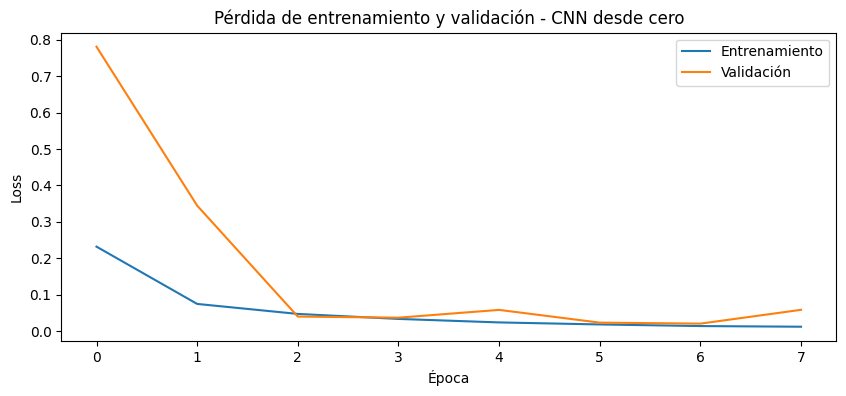

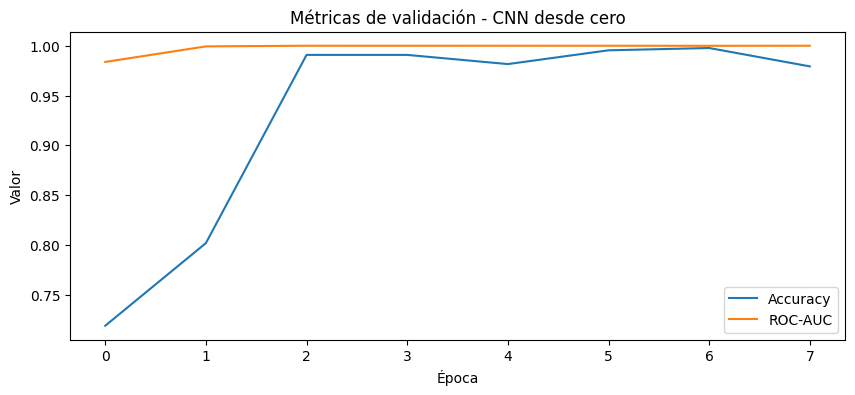

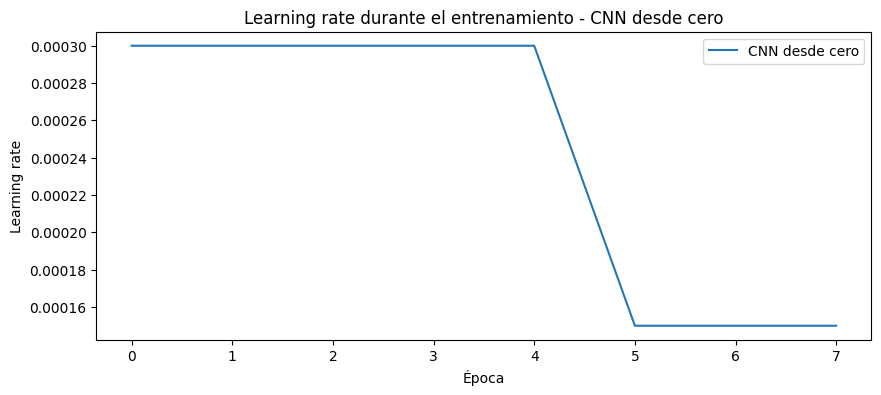

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    history_scratch["val_loss"],
    label="Validación"
)

plt.title("Pérdida de entrenamiento y validación - CNN desde cero")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación - CNN desde cero")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    history_scratch["lr"],
    label="CNN desde cero"
)
plt.title("Learning rate durante el entrenamiento - CNN desde cero")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

Después de entrenar el modelo voy a utilizar el conjunto de **test** para medir su comportamiento con imágenes que no fueron utilizadas durante el entrenamiento.

Aquí voy a mostrar:

- Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1 por clase.

El conjunto de test lo dejo para esta etapa para no utilizarlo durante las decisiones del entrenamiento.


In [16]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch,
    test_loader
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=selected_names,
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.9942
Test ROC-AUC: 0.9998

              precision    recall  f1-score   support

    basophil     0.9878    0.9918    0.9898       244
  eosinophil     0.9968    0.9952    0.9960       624

    accuracy                         0.9942       868
   macro avg     0.9923    0.9935    0.9929       868
weighted avg     0.9943    0.9942    0.9942       868



array([[242,   2],
       [  3, 621]])

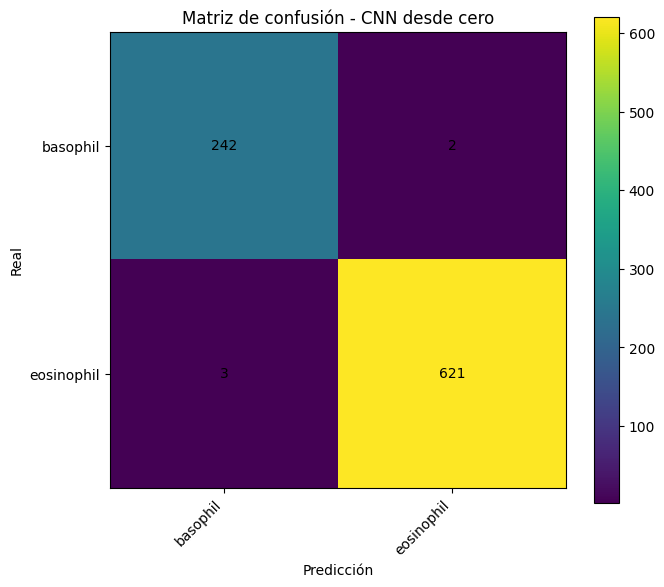

In [17]:
plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Matriz de confusión - CNN desde cero")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    range(num_classes),
    selected_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_classes),
    selected_names
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

En esta parte voy a probar **data augmentation**.

La idea es generar pequeñas variaciones de las imágenes de entrenamiento para que el modelo no memorice tan fácilmente los ejemplos originales.

Voy a utilizar aumentos moderados. No quiero transformar demasiado las imágenes porque siguen representando células y una transformación muy fuerte podría cambiar características importantes de ellas.

Después voy a comparar este modelo con la CNN que entrené sin augmentation para observar si existe alguna diferencia.


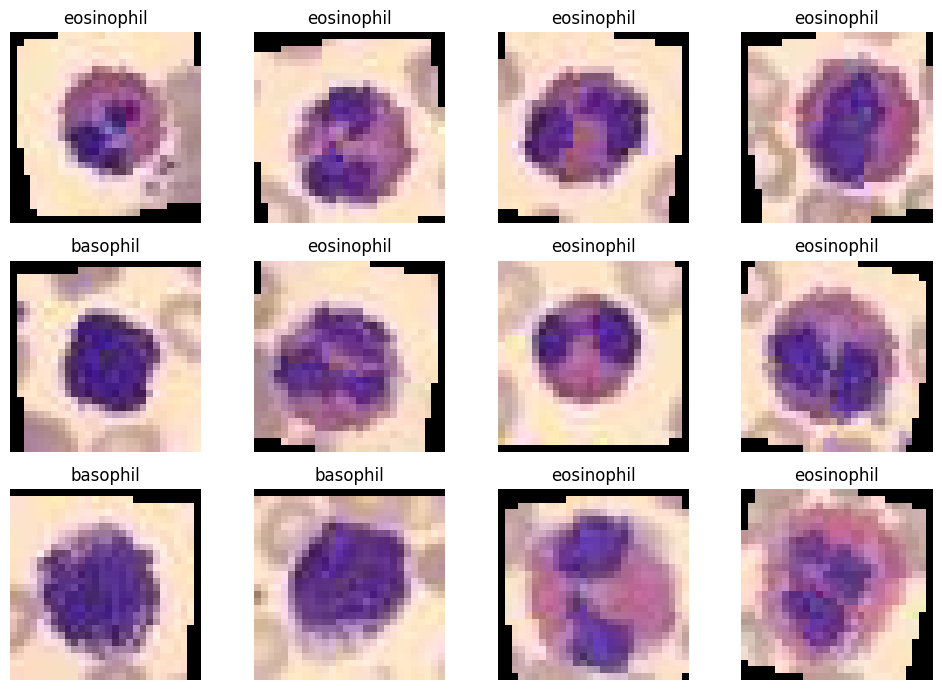

In [18]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=15),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.ToTensor()
])

train_full_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

train_dataset_aug = Subset(
    train_full_aug,
    train_indices
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

show_batch(train_dataset_aug, n=12)


In [19]:
model_aug = BloodCNN(num_classes=num_classes).to(device)

criterion_aug = nn.CrossEntropyLoss()

optimizer_aug = torch.optim.AdamW(
    model_aug.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug,
    mode="max",
    factor=0.5,
    patience=2
)

epochs = 20
patience = 5

history_aug = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

best_val_auc_aug = -np.inf
best_state_aug = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion_aug
    )

    val_loss = validation_loss(
        model_aug,
        val_loader,
        criterion_aug
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    scheduler_aug.step(val_auc)

    current_lr = optimizer_aug.param_groups[0]["lr"]

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)
    history_aug["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    if val_auc > best_val_auc_aug:
        best_val_auc_aug = val_auc
        best_state_aug = {
            k: v.detach().cpu().clone()
            for k, v in model_aug.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping activado.")
        break

if best_state_aug is not None:
    model_aug.load_state_dict(best_state_aug)

print(f"Mejor ROC-AUC de validación con augmentation: {best_val_auc_aug:.4f}")

Epoch 01 | train_loss=0.3555 | val_loss=0.6035 | val_acc=0.7189 | val_auc=0.9908 | lr=0.000300
Epoch 02 | train_loss=0.1226 | val_loss=0.1853 | val_acc=0.9101 | val_auc=0.9993 | lr=0.000300
Epoch 03 | train_loss=0.0727 | val_loss=0.0703 | val_acc=0.9839 | val_auc=0.9997 | lr=0.000300
Epoch 04 | train_loss=0.0593 | val_loss=0.0454 | val_acc=0.9954 | val_auc=0.9999 | lr=0.000300
Epoch 05 | train_loss=0.0499 | val_loss=0.0454 | val_acc=0.9908 | val_auc=0.9998 | lr=0.000300
Epoch 06 | train_loss=0.0407 | val_loss=0.0397 | val_acc=0.9931 | val_auc=0.9999 | lr=0.000300
Epoch 07 | train_loss=0.0395 | val_loss=0.0736 | val_acc=0.9793 | val_auc=1.0000 | lr=0.000300
Epoch 08 | train_loss=0.0332 | val_loss=0.0718 | val_acc=0.9700 | val_auc=0.9998 | lr=0.000300
Epoch 09 | train_loss=0.0277 | val_loss=0.0681 | val_acc=0.9793 | val_auc=1.0000 | lr=0.000300
Epoch 10 | train_loss=0.0266 | val_loss=0.0205 | val_acc=0.9954 | val_auc=0.9999 | lr=0.000150
Epoch 11 | train_loss=0.0217 | val_loss=0.0227 | v

### 6.1. Comparación rápida

Ahora voy a comparar la CNN sin augmentation con la CNN que utiliza augmentation.

No voy a fijarme solamente en cuál tiene el Accuracy más alto. También voy a revisar el comportamiento de entrenamiento y validación para ver si el modelo está generalizando bien.

Si el augmentation ayuda a reducir la diferencia entre entrenamiento y validación, sería una señal de que está ayudando a controlar el overfitting.


También comparo el **learning rate** de ambos entrenamientos para observar cómo `ReduceLROnPlateau` ajusta el ritmo de aprendizaje en cada caso.


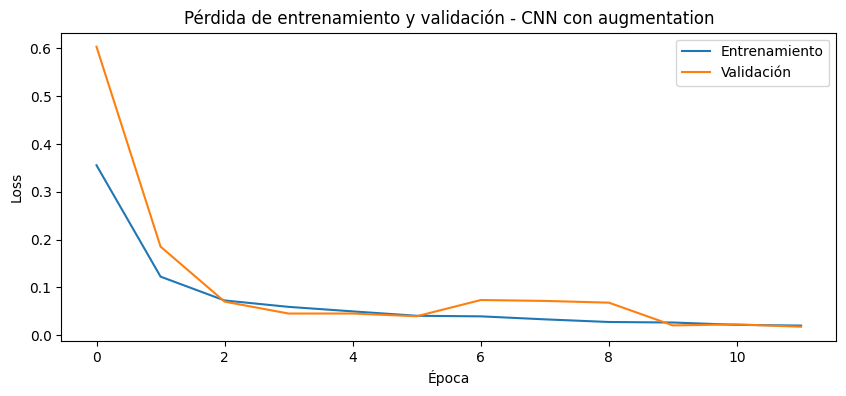

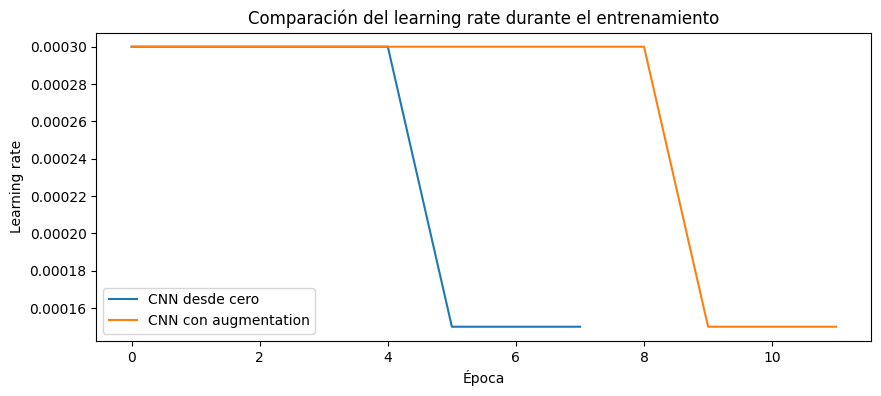

In [20]:
plt.figure(figsize=(10, 4))

plt.plot(
    history_aug["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    history_aug["val_loss"],
    label="Validación"
)

plt.title("Pérdida de entrenamiento y validación - CNN con augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Comparación del learning rate entre ambos entrenamientos
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["lr"],
    label="CNN desde cero"
)

plt.plot(
    history_aug["lr"],
    label="CNN con augmentation"
)

plt.title("Comparación del learning rate durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.legend()
plt.show()


In [21]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print(
    f"Sin augmentation | "
    f"test_acc={test_acc:.4f} | "
    f"test_auc={test_auc:.4f}"
)

print(
    f"Con augmentation | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)


Sin augmentation | test_acc=0.9942 | test_auc=0.9998
Con augmentation | test_acc=0.9885 | test_auc=0.9999


## 7. Transfer Learning en BloodMNIST

Ahora voy a probar **Transfer Learning** utilizando una ResNet18 que ya fue entrenada previamente con ImageNet.

En este caso BloodMNIST trabaja con imágenes RGB, por lo que la entrada de ResNet18 ya es compatible con el formato de las imágenes.

La ventaja de esta opción es que la red ya tiene características visuales aprendidas y puedo reutilizarlas para el nuevo problema de clasificación.


In [22]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=15),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.ToTensor()
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

train_full_tl = DataClass(
    split="train",
    transform=transform_tl_train,
    download=True
)

val_full_tl = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=True
)

test_full_tl = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=True
)

train_dataset_tl = Subset(train_full_tl, train_indices)
val_dataset_tl = Subset(val_full_tl, val_indices)
test_dataset_tl = Subset(test_full_tl, test_indices)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Primero voy a cargar ResNet18 con sus pesos preentrenados.

Después voy a congelar la mayor parte de la red para no modificar todas las características que ya aprendió. Solamente voy a reemplazar la capa final `fc` para que la salida tenga el número de clases de BloodMNIST.

Con esto también reduzco la cantidad de parámetros que necesito entrenar y disminuyo el riesgo de overfitting.


In [23]:
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, num_classes)
)

resnet = resnet.to(device)

for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
criterion_tl = nn.CrossEntropyLoss()

optimizer_tl = torch.optim.AdamW(
    resnet.fc.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl,
    mode="max",
    factor=0.5,
    patience=1
)

epochs = 8

history_tl_stage1 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer_tl,
        criterion_tl
    )

    val_loss = validation_loss(
        resnet,
        val_loader_tl,
        criterion_tl
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    scheduler_tl.step(val_auc)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.4836 | val_loss=0.3183 | val_acc=0.8479 | val_auc=0.9887
Stage1 Epoch 02 | train_loss=0.2913 | val_loss=0.2445 | val_acc=0.8848 | val_auc=0.9942
Stage1 Epoch 03 | train_loss=0.2286 | val_loss=0.2130 | val_acc=0.9009 | val_auc=0.9960
Stage1 Epoch 04 | train_loss=0.1993 | val_loss=0.1731 | val_acc=0.9332 | val_auc=0.9967
Stage1 Epoch 05 | train_loss=0.1675 | val_loss=0.1556 | val_acc=0.9424 | val_auc=0.9971
Stage1 Epoch 06 | train_loss=0.1690 | val_loss=0.1289 | val_acc=0.9631 | val_auc=0.9975
Stage1 Epoch 07 | train_loss=0.1502 | val_loss=0.1172 | val_acc=0.9677 | val_auc=0.9975
Stage1 Epoch 08 | train_loss=0.1392 | val_loss=0.1032 | val_acc=0.9677 | val_auc=0.9977


### 7.2. Fine-tuning controlado

Después de entrenar el clasificador, voy a hacer un **fine-tuning controlado**.

En lugar de descongelar toda la ResNet18, solamente voy a permitir que se actualicen `layer4` y `fc`.

Lo hago de esta manera porque descongelar toda la red tendría muchos más parámetros entrenables y podría aumentar el riesgo de sobreajuste. Así puedo adaptar algunas características de la red al BloodMNIST sin modificar completamente el modelo preentrenado.


In [25]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

print(
    "Parámetros entrenables:",
    sum(p.numel() for p in trainable_params)
)

Parámetros entrenables: 8394754


In [26]:
optimizer_tl = torch.optim.AdamW(
    trainable_params,
    lr=5e-5,
    weight_decay=1e-4
)

scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl,
    mode="max",
    factor=0.5,
    patience=1
)

epochs = 8
patience = 3

history_tl_stage2 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

best_val_auc_tl = -np.inf
best_state_tl = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer_tl,
        criterion_tl
    )

    val_loss = validation_loss(
        resnet,
        val_loader_tl,
        criterion_tl
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    scheduler_tl.step(val_auc)

    current_lr = optimizer_tl.param_groups[0]["lr"]

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["lr"].append(current_lr)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    if val_auc > best_val_auc_tl:
        best_val_auc_tl = val_auc
        best_state_tl = {
            k: v.detach().cpu().clone()
            for k, v in resnet.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping del fine-tuning.")
        break

if best_state_tl is not None:
    resnet.load_state_dict(best_state_tl)

print(f"Mejor ROC-AUC de validación TL: {best_val_auc_tl:.4f}")

Stage2 Epoch 01 | train_loss=0.0697 | val_loss=0.0315 | val_acc=0.9862 | val_auc=0.9994 | lr=0.000050
Stage2 Epoch 02 | train_loss=0.0377 | val_loss=0.0245 | val_acc=0.9931 | val_auc=0.9997 | lr=0.000050
Stage2 Epoch 03 | train_loss=0.0319 | val_loss=0.0208 | val_acc=0.9954 | val_auc=0.9998 | lr=0.000050
Stage2 Epoch 04 | train_loss=0.0205 | val_loss=0.0144 | val_acc=0.9954 | val_auc=0.9999 | lr=0.000050
Stage2 Epoch 05 | train_loss=0.0139 | val_loss=0.0205 | val_acc=0.9954 | val_auc=0.9999 | lr=0.000025
Stage2 Epoch 06 | train_loss=0.0187 | val_loss=0.0245 | val_acc=0.9908 | val_auc=0.9999 | lr=0.000025
Stage2 Epoch 07 | train_loss=0.0114 | val_loss=0.0159 | val_acc=0.9954 | val_auc=0.9999 | lr=0.000025
Stage2 Epoch 08 | train_loss=0.0125 | val_loss=0.0170 | val_acc=0.9931 | val_auc=0.9999 | lr=0.000013
Mejor ROC-AUC de validación TL: 0.9999


### 7.3. Evaluación en test del modelo con transfer learning

Ahora voy a evaluar el modelo de ResNet18 utilizando el conjunto de test.

Voy a utilizar las mismas métricas que en la CNN para poder comparar los resultados de una manera más clara.


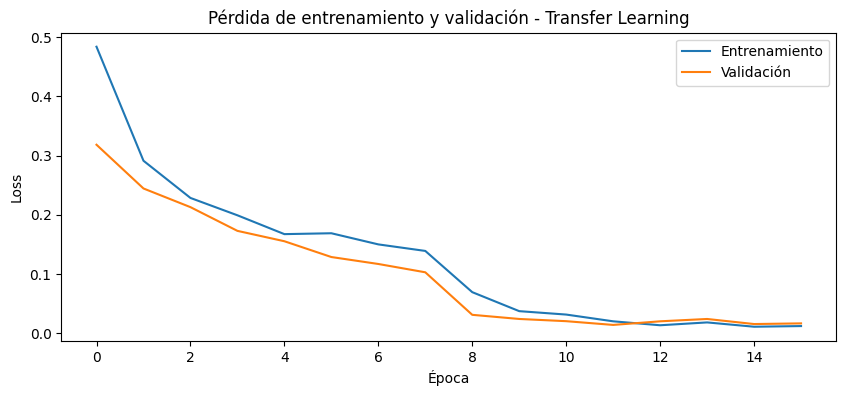

In [27]:
train_loss_tl = (
    history_tl_stage1["train_loss"]
    + history_tl_stage2["train_loss"]
)

val_loss_tl = (
    history_tl_stage1["val_loss"]
    + history_tl_stage2["val_loss"]
)

plt.figure(figsize=(10, 4))

plt.plot(
    train_loss_tl,
    label="Entrenamiento"
)

plt.plot(
    val_loss_tl,
    label="Validación"
)

plt.title("Pérdida de entrenamiento y validación - Transfer Learning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [28]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(f"Transfer learning | test_acc={test_acc_tl:.4f}")
print(f"Transfer learning | test_auc={test_auc_tl:.4f}")
print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=selected_names,
        digits=4
    )
)

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9896
Transfer learning | test_auc=0.9998

              precision    recall  f1-score   support

    basophil     1.0000    0.9631    0.9812       244
  eosinophil     0.9858    1.0000    0.9928       624

    accuracy                         0.9896       868
   macro avg     0.9929    0.9816    0.9870       868
weighted avg     0.9898    0.9896    0.9896       868



array([[235,   9],
       [  0, 624]])

### 7.4. Comparación global

Finalmente voy a comparar los tres modelos que entrené:

- CNN desde cero.
- CNN con augmentation.
- ResNet18 con Transfer Learning.

Además de revisar las métricas, también voy a considerar el comportamiento de entrenamiento y validación.

No quiero elegir un modelo solamente porque tenga un número alto en Accuracy. También me interesa que tenga una diferencia razonable entre entrenamiento y validación y que no presente un overfitting muy marcado.


In [29]:
print("Resumen de resultados en test")
print(
    f"CNN desde cero       | "
    f"acc={test_acc:.4f} | auc={test_auc:.4f}"
)
print(
    f"CNN con augmentation | "
    f"acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)
print(
    f"Transfer learning    | "
    f"acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN desde cero       | acc=0.9942 | auc=0.9998
CNN con augmentation | acc=0.9885 | auc=0.9999
Transfer learning    | acc=0.9896 | auc=0.9998


## 8. Interpretabilidad básica: Grad-CAM

En esta parte voy a utilizar **Grad-CAM** para observar qué zonas de la imagen tienen mayor influencia en la predicción del modelo.

Esto me permite tener una idea de si el modelo está prestando atención a la zona donde realmente se encuentra la célula o si está utilizando otras partes de la imagen.

No significa que Grad-CAM explique completamente el funcionamiento de la red, pero sirve como una forma visual de revisar la predicción.


In [30]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()

    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))

    if target_class is None:
        target_class = int(
            torch.argmax(logits, dim=1).item()
        )

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


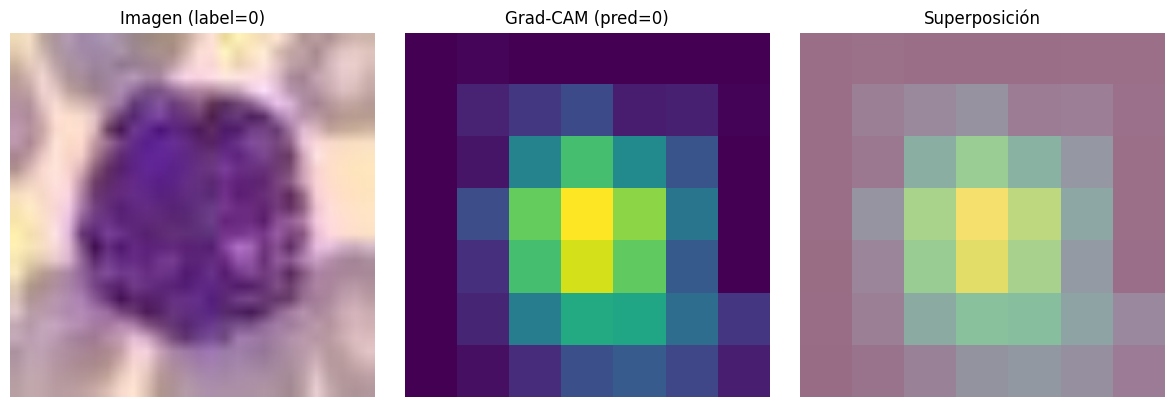

In [31]:
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

img = x.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(
    f"Imagen (label={int(y.item())})"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(
    f"Grad-CAM (pred={pred_class})"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Buenas prácticas para evitar overfitting

En este trabajo estoy aplicando varias medidas para tratar de mantener el overfitting lo más bajo posible:

1. **Separación de train, validation y test**  
   Mantengo el conjunto de test separado y lo utilizo solamente para la evaluación final.

2. **BatchNorm**  
   Lo utilizo para ayudar a estabilizar el entrenamiento de la CNN.

3. **Dropout**  
   Lo utilizo como regularización para evitar que la red dependa demasiado de determinadas neuronas.

4. **Data augmentation moderado**  
   Agrego pequeñas variaciones a las imágenes de entrenamiento para aumentar su variedad.

5. **Weight decay**  
   Lo utilizo para regularizar los pesos del modelo.

6. **Learning rate scheduler**  
   Si la validación deja de mejorar, reduzco el learning rate.

7. **Early stopping**  
   Si durante varias épocas la validación no mejora, detengo el entrenamiento.

8. **Fine-tuning limitado**  
   En ResNet18 no descongelo toda la red, sino solamente `layer4` y `fc`.

9. **Revisión de las curvas**  
   Comparo entrenamiento y validación para detectar si aparece una diferencia demasiado grande.

Para mí, una señal de overfitting sería que el modelo siga mejorando mucho en entrenamiento mientras la validación deja de mejorar o empieza a empeorar. Por eso guardo el mejor estado obtenido durante la validación y no simplemente el de la última época.


## 10. Guardar y cargar modelos

Al terminar voy a guardar los modelos entrenados para poder utilizarlos nuevamente sin tener que repetir todo el entrenamiento.

Voy a guardar la CNN desde cero, la CNN con augmentation y la ResNet18 con Transfer Learning.


In [32]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model_scratch.state_dict(),
    "models/bloodmnist_cnn_scratch.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/bloodmnist_cnn_aug.pth"
)

torch.save(
    resnet.state_dict(),
    "models/bloodmnist_resnet_transfer.pth"
)

[
    "models/bloodmnist_cnn_scratch.pth",
    "models/bloodmnist_cnn_aug.pth",
    "models/bloodmnist_resnet_transfer.pth"
]

['models/bloodmnist_cnn_scratch.pth',
 'models/bloodmnist_cnn_aug.pth',
 'models/bloodmnist_resnet_transfer.pth']